In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [6]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

X.head()

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
linear_svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

SVC(kernel='linear', probability=True, random_state=42)

In [10]:
linear_pred = linear_svm.predict(
    X_test_scaled
)

linear_prob = linear_svm.predict_proba(
    X_test_scaled
)[:,1]

In [11]:
print("Linear Kernel Results")

print("Accuracy:",
      accuracy_score(y_test, linear_pred))

print("Precision:",
      precision_score(y_test, linear_pred))

print("Recall:",
      recall_score(y_test, linear_pred))

print("F1 Score:",
      f1_score(y_test, linear_pred))

print("AUC:",
      roc_auc_score(y_test, linear_prob))

Linear Kernel Results
Accuracy: 0.9736842105263158
Precision: 0.9859154929577465
Recall: 0.9722222222222222
F1 Score: 0.9790209790209791
AUC: 0.9963624338624338


In [12]:
rbf_svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

In [13]:
rbf_pred = rbf_svm.predict(
    X_test_scaled
)

rbf_prob = rbf_svm.predict_proba(
    X_test_scaled
)[:,1]

In [14]:
print("RBF Kernel Results")

print("Accuracy:",
      accuracy_score(y_test, rbf_pred))

print("Precision:",
      precision_score(y_test, rbf_pred))

print("Recall:",
      recall_score(y_test, rbf_pred))

print("F1 Score:",
      f1_score(y_test, rbf_pred))

print("AUC:",
      roc_auc_score(y_test, rbf_prob))

RBF Kernel Results
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
AUC: 0.9950396825396826


In [15]:
print("RBF Kernel Results")

print("Accuracy:",
      accuracy_score(y_test, rbf_pred))

print("Precision:",
      precision_score(y_test, rbf_pred))

print("Recall:",
      recall_score(y_test, rbf_pred))

print("F1 Score:",
      f1_score(y_test, rbf_pred))

print("AUC:",
      roc_auc_score(y_test, rbf_prob))

RBF Kernel Results
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
AUC: 0.9950396825396826


In [16]:
comparison = pd.DataFrame({

    'Kernel': ['Linear', 'RBF'],

    'Accuracy': [
        accuracy_score(y_test, linear_pred),
        accuracy_score(y_test, rbf_pred)
    ],

    'Precision': [
        precision_score(y_test, linear_pred),
        precision_score(y_test, rbf_pred)
    ],

    'Recall': [
        recall_score(y_test, linear_pred),
        recall_score(y_test, rbf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, linear_pred),
        f1_score(y_test, rbf_pred)
    ]
})

print(comparison)

   Kernel  Accuracy  Precision    Recall  F1 Score
0  Linear  0.973684   0.985915  0.972222  0.979021
1     RBF  0.982456   0.986111  0.986111  0.986111


In [17]:
print("Linear Kernel")

print(
    classification_report(
        y_test,
        linear_pred
    )
)

print("\nRBF Kernel")

print(
    classification_report(
        y_test,
        rbf_pred
    )
)

Linear Kernel
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


RBF Kernel
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [19]:
linear_fpr, linear_tpr, _ = roc_curve(
    y_test,
    linear_prob
)

rbf_fpr, rbf_tpr, _ = roc_curve(
    y_test,
    rbf_prob
)

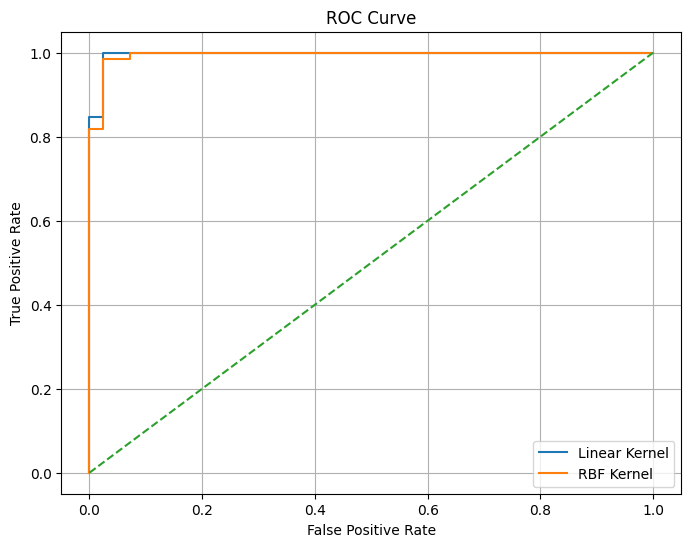

In [20]:
plt.figure(figsize=(8,6))

plt.plot(
    linear_fpr,
    linear_tpr,
    label="Linear Kernel"
)

plt.plot(
    rbf_fpr,
    rbf_tpr,
    label="RBF Kernel"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled := scaler.fit_transform(X))

In [22]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
svm_2d = SVC(
    kernel='rbf'
)

svm_2d.fit(
    X_train_pca,
    y_train_pca
)

SVC()

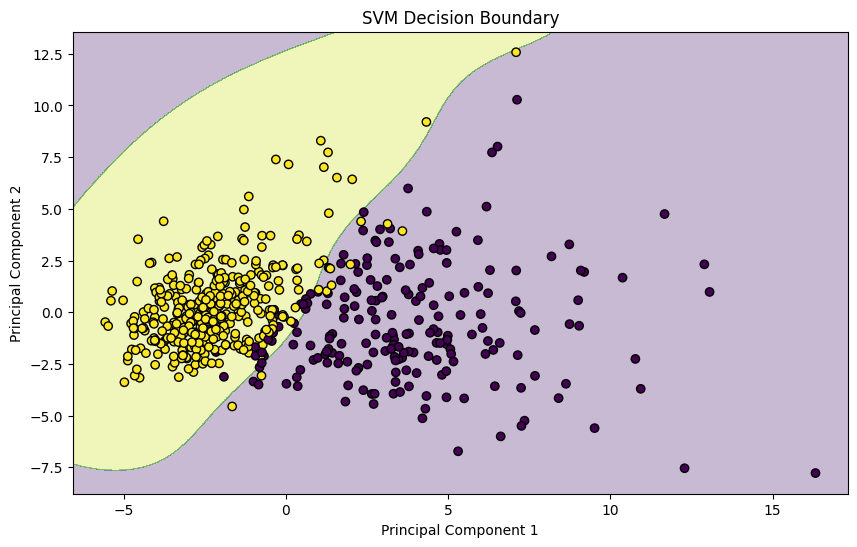

In [24]:
h = 0.02

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    edgecolors='k'
)

plt.title("SVM Decision Boundary")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()